<a href="https://colab.research.google.com/github/SupriyaSakshana/Aerial-Object-Classification-Detection/blob/main/CNN%20and%20Transient%20Model%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

print(os.listdir("/content"))

['.config', 'sample_data']


In [2]:
import gdown

file_id = "1B_UArqFmXjeIKqPGHqt77rUJaHGLigIJ"
output = "/content/dataset.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1B_UArqFmXjeIKqPGHqt77rUJaHGLigIJ
From (redirected): https://drive.google.com/uc?id=1B_UArqFmXjeIKqPGHqt77rUJaHGLigIJ&confirm=t&uuid=3eeb407c-0082-4108-a0bd-529b40463918
To: /content/dataset.zip
100%|██████████| 81.6M/81.6M [00:00<00:00, 101MB/s] 


'/content/dataset.zip'

In [3]:
import zipfile
import os

extract_path = "/content/dataset"

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [4]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/classification_dataset
/content/dataset/classification_dataset/valid
/content/dataset/classification_dataset/valid/bird
/content/dataset/classification_dataset/valid/drone
/content/dataset/classification_dataset/train
/content/dataset/classification_dataset/train/bird
/content/dataset/classification_dataset/train/drone
/content/dataset/classification_dataset/test
/content/dataset/classification_dataset/test/bird
/content/dataset/classification_dataset/test/drone


In [5]:
train_dir = "/content/dataset/classification_dataset/train"
val_dir = "/content/dataset/classification_dataset/valid"
test_dir = "/content/dataset/classification_dataset/test"

Understand the Dataset

(A) Inspect Folder Structure

In [6]:
import os

for root, dirs, files in os.walk(train_dir):
    print(f"Folder: {root}")
    print(f"Subfolders: {dirs}")
    print(f"Number of files: {len(files)}\n")

Folder: /content/dataset/classification_dataset/train
Subfolders: ['bird', 'drone']
Number of files: 0

Folder: /content/dataset/classification_dataset/train/bird
Subfolders: []
Number of files: 1414

Folder: /content/dataset/classification_dataset/train/drone
Subfolders: []
Number of files: 1248



(B) Count Images per Class

In [7]:
import os

def count_images(path):
    classes = os.listdir(path)
    for cls in classes:
        cls_path = os.path.join(path, cls)
        print(f"{cls}: {len(os.listdir(cls_path))} images")

print("Train Data:")
count_images(train_dir)

print("\nValidation Data:")
count_images(val_dir)

print("\nTest Data:")
count_images(test_dir)

Train Data:
bird: 1414 images
drone: 1248 images

Validation Data:
bird: 217 images
drone: 225 images

Test Data:
bird: 121 images
drone: 94 images


C) Check Class Imbalance

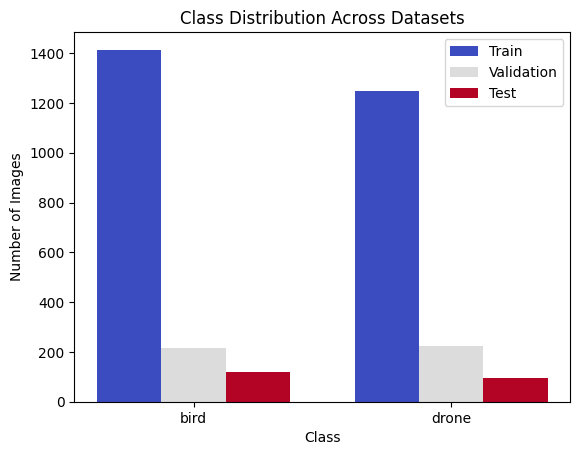

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

def combined_plot(train_dir, val_dir, test_dir):
    classes = os.listdir(train_dir)

    train_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
    val_counts = [len(os.listdir(os.path.join(val_dir, cls))) for cls in classes]
    test_counts = [len(os.listdir(os.path.join(test_dir, cls))) for cls in classes]

    x = np.arange(len(classes))
    width = 0.25

    # 🎨 coolwarm colormap
    colors = plt.cm.coolwarm(np.linspace(0, 1, 3))

    plt.figure()
    plt.bar(x - width, train_counts, width, label='Train', color=colors[0])
    plt.bar(x, val_counts, width, label='Validation', color=colors[1])
    plt.bar(x + width, test_counts, width, label='Test', color=colors[2])

    plt.xticks(x, classes)
    plt.title("Class Distribution Across Datasets")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.legend()
    plt.show()

combined_plot(train_dir, val_dir, test_dir)

(D) Visualize Sample Images

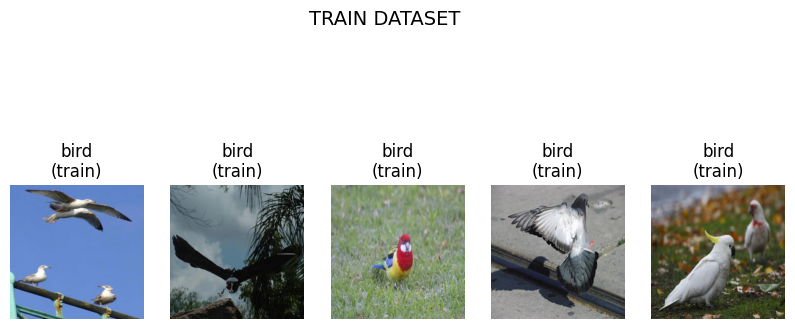

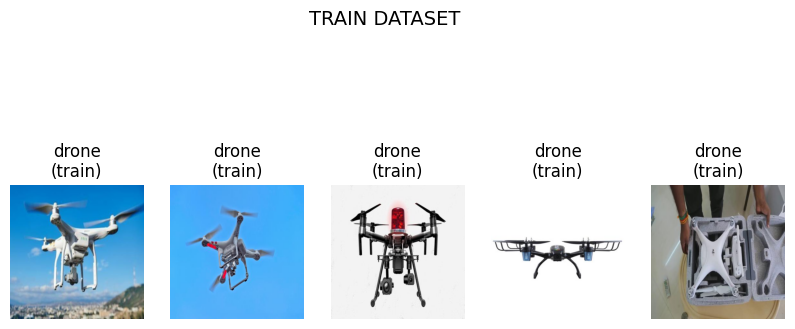

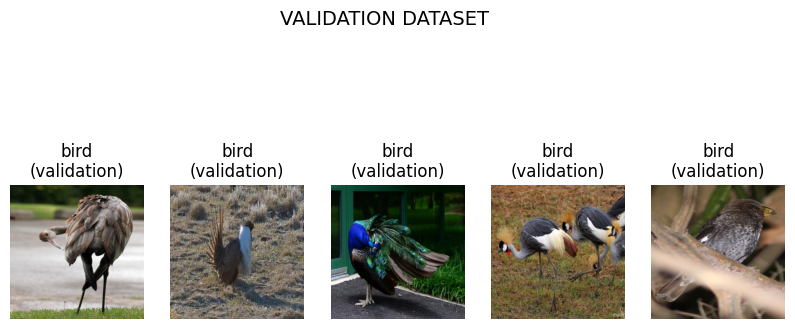

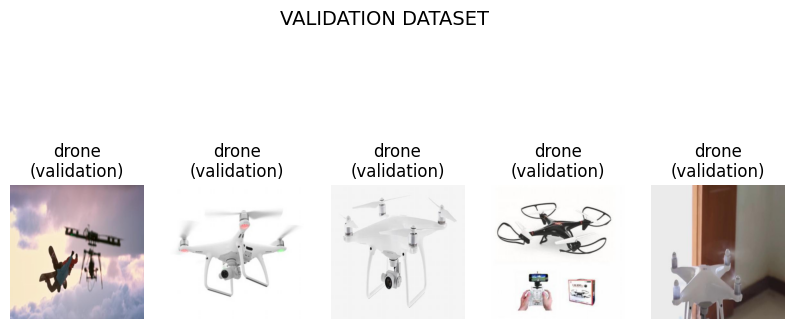

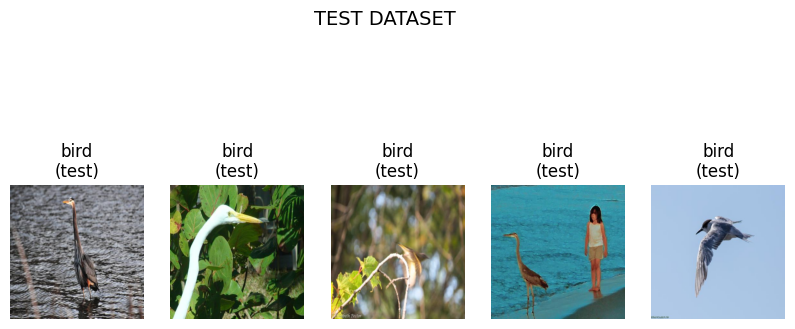

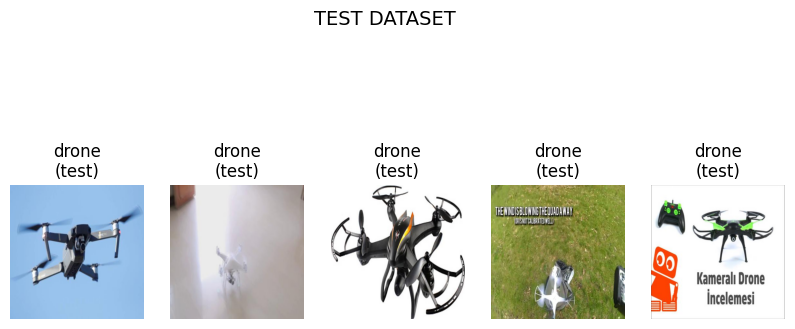

In [9]:
import matplotlib.pyplot as plt
import random
from PIL import Image
import os

def show_images(path, class_name, dataset_name):
    folder = os.path.join(path, class_name)
    images = random.sample(os.listdir(folder), 5)

    plt.figure(figsize=(10,5))
    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(f"{class_name}\n({dataset_name})")  # <-- dataset name added
        plt.axis('off')
    plt.suptitle(f"{dataset_name.upper()} DATASET", fontsize=14)
    plt.show()

# -------- TRAIN --------
show_images(train_dir, "bird", "train")
show_images(train_dir, "drone", "train")

# -------- VALIDATION --------
show_images(val_dir, "bird", "validation")
show_images(val_dir, "drone", "validation")

# -------- TEST --------
show_images(test_dir, "bird", "test")
show_images(test_dir, "drone", "test")

2. Data Preprocessing Normalize pixel values to [0, 1]
Resize images to a fixed size (224×224 for classification)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create data generator with normalization
train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load & preprocess data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   # resize
    batch_size=32,
    class_mode='categorical'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


Using PIL + NumPy

In [11]:
import numpy as np
from PIL import Image
import os

def preprocess_image(img_path):
    img = Image.open(img_path)
    img = img.resize((224, 224))        # resize
    img = np.array(img) / 255.0         # normalize
    return img

Data Loading (Keras)

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,              # normalization
    rotation_range=30,           # rotate images
    width_shift_range=0.1,       # horizontal shift (cropping effect)
    height_shift_range=0.1,      # vertical shift
    zoom_range=0.2,              # zoom in/out
    horizontal_flip=True,        # flip images
    brightness_range=[0.8, 1.2], # brightness adjustment
    fill_mode='nearest'          # fill missing pixels
)

# Validation & Test (NO augmentation ❗ only normalization)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load datasets
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary' # Changed from 'categorical' to 'binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary' # Changed from 'categorical' to 'binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary', # Changed from 'categorical' to 'binary'
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


Found 2662 images belonging to 2 classes.


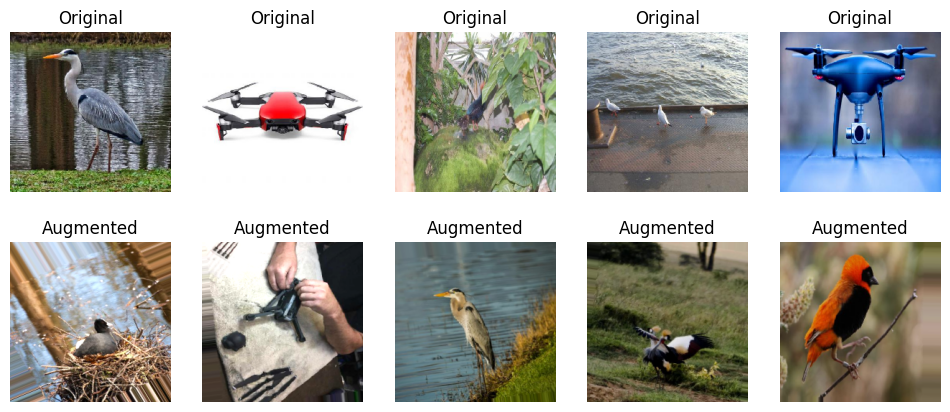

In [13]:
# ORIGINAL (without augmentation)
original_datagen = ImageDataGenerator(rescale=1./255)

original_data = original_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=5,
    class_mode='categorical'
)

orig_images, _ = next(original_data)
aug_images, _ = next(train_data)

plt.figure(figsize=(12,5))

for i in range(5):
    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(orig_images[i])
    plt.title("Original")
    plt.axis('off')

    # Augmented
    plt.subplot(2,5,i+6)
    plt.imshow(aug_images[i])
    plt.title("Augmented")
    plt.axis('off')

plt.show()

Custom CNN Model

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Best validation loss was 0.36360 Trying to Improve my model by using Dropout layers, BatchNormalization

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential([
    # -------- Block 1 --------
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # -------- Block 2 --------
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # -------- Block 3 --------
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # -------- Fully Connected --------
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    # -------- Output --------
    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
from tensorflow.keras.metrics import Precision, Recall

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
)

Training

In [17]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 57s 558ms/step - accuracy: 0.6488 - loss: 5.2426 - precision: 0.6235 - recall: 0.6330 - val_accuracy: 0.6606 - val_loss: 4.0204 - val_precision: 0.9630 - val_recall: 0.3467
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 470ms/step - accuracy: 0.6844 - loss: 0.9571 - precision: 0.6802 - recall: 0.6170 - val_accuracy: 0.5656 - val_loss: 0.9614 - val_precision: 0.5563 - val_recall: 0.7244
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 476ms/step - accuracy: 0.7239 - loss: 0.5900 - precision: 0.7296 - recall: 0.6530 - val_accuracy: 0.5452 - val_loss: 0.9078 - val_precision: 0.6622 - val_recall: 0.2178
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 41s 481ms/step - accuracy: 0.7292 - loss: 0.5538 - precision: 0.7507 - recall: 0.6322 - val_accuracy: 0.6900 - val_loss: 0.5375 - val_precision: 0.7716 - val_recall: 0.5556
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 472ms/step - accuracy: 0.7562 - loss: 0.5899 - precision: 0.7796 - recall: 0.6691 - val_accuracy: 0.6403 - val_los

In [18]:
model.save("final_model.keras")

In [19]:
from tensorflow.keras.models import load_model

load_model("final_model.keras")

<Sequential name=sequential_1, built=True>

In [ ]:
from google.colab import files
files.download("final_model.keras")

In [20]:
import os
os.listdir()

['.config', 'dataset', 'dataset.zip', 'final_model.keras', 'sample_data']

In [21]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [22]:
model.save("model.h5", save_format="h5")

In [ ]:
from google.colab import files
files.download("model.h5")

In [23]:
# Save full model (recommended)
model.save("Custom_model.keras")
print("Model saved as 'Custom_model.keras'")

Model saved as 'Custom_model.keras'


load instead of saving:

In [24]:
from tensorflow import keras

model = keras.models.load_model("Custom_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from google.colab import files

files.download("Custom_model.keras")

In [25]:
from tensorflow import keras

model = keras.models.load_model("Custom_model.keras", compile=False)

In [26]:
import os
print(os.path.getsize("Custom_model.keras"))

134101370


In [27]:
from tensorflow import keras

model = keras.models.load_model("Custom_model.keras", compile=False)

Evaluation

In [32]:
def evaluate_model(model, data, name):
    loss, acc = model.evaluate(data, verbose=0)

    print(f"\n{name} RESULTS")
    print("-" * 30)
    print(f"Accuracy : {acc:.4f}")
    print(f"Loss     : {loss:.4f}")

# Call it
compile_model(model) # Recompile the model
evaluate_model(model, test_data, "TEST DATA")

NameError: name 'compile_model' is not defined

In [29]:
from tensorflow import keras

best_model = keras.models.load_model("Custom_model.keras")

def evaluate_model(data, name):
    loss, acc, prec, rec = best_model.evaluate(data, verbose=0)

    # F1 Score calculation
    if (prec + rec) == 0:
        f1 = 0
    else:
        f1 = 2 * (prec * rec) / (prec + rec)

    print(f"\n{name} RESULTS")
    print("-" * 30)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Loss      : {loss:.4f}")

# Run for all datasets
evaluate_model(train_data, "TRAIN")
evaluate_model(val_data, "VALIDATION")
evaluate_model(test_data, "TEST")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 18 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



TRAIN RESULTS
------------------------------
Accuracy  : 0.8347
Precision : 0.9000
Recall    : 0.7284
F1 Score  : 0.8051
Loss      : 0.3559

VALIDATION RESULTS
------------------------------
Accuracy  : 0.8009
Precision : 0.8374
Recall    : 0.7556
F1 Score  : 0.7944
Loss      : 0.4279

TEST RESULTS
------------------------------
Accuracy  : 0.8279
Precision : 0.8701
Recall    : 0.7128
F1 Score  : 0.7836
Loss      : 0.3441


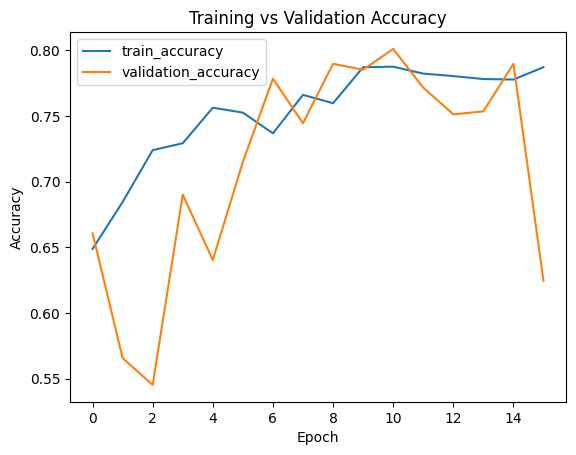

In [33]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='validation_accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

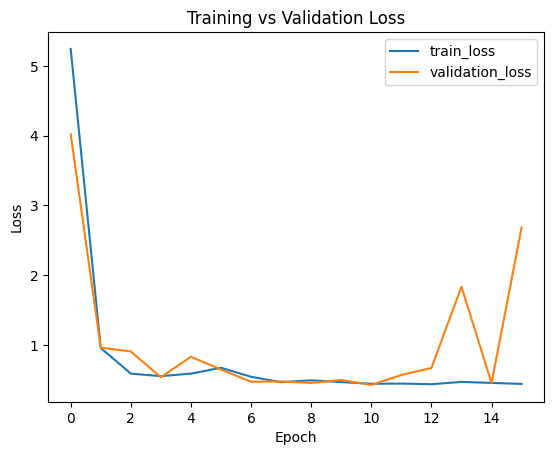

In [34]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='validation_loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

Transfer Learning Code (MobileNetV2)

In [35]:
import tensorflow as tf
from tensorflow.keras import layers, models

2. Function to Build Transfer Learning Model

In [36]:
def build_model(base_model, num_classes=1):
    base_model.trainable = False  # freeze base

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),

        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='sigmoid')  # binary
    ])

    return model

3. Load Different Pretrained Models

(A) MobileNetV2

In [37]:
from tensorflow.keras.applications import MobileNetV2

base_mobilenet = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

model_mobilenet = build_model(base_mobilenet)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(B) ResNet50

In [38]:
from tensorflow.keras.applications import ResNet50

base_resnet = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

model_resnet = build_model(base_resnet)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(C) EfficientNetB0 (Best 🔥

In [39]:
from tensorflow.keras.applications import EfficientNetB0

base_efficient = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

model_efficient = build_model(base_efficient)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


4. Compile Model

In [40]:
import tensorflow as tf
from tensorflow.keras.metrics import Precision, Recall

def compile_model(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(), Recall()]
    )

5. Train (Initial Training)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

compile_model(model_efficient)   # or model_resnet / model_mobilenet

history = model_efficient.fit(
    train_data,
    validation_data=val_data,
    epochs=25,callbacks=[early_stop]
)

Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 866ms/step - accuracy: 0.5113 - loss: 0.7442 - precision: 0.4751 - recall: 0.4046 - val_accuracy: 0.5090 - val_loss: 0.6951 - val_precision: 0.5090 - val_recall: 1.0000
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 480ms/step - accuracy: 0.5188 - loss: 0.7337 - precision: 0.4846 - recall: 0.4159 - val_accuracy: 0.5090 - val_loss: 0.6929 - val_precision: 0.5090 - val_recall: 1.0000
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 478ms/step - accuracy: 0.5214 - loss: 0.7271 - precision: 0.4876 - recall: 0.4111 - val_accuracy: 0.5113 - val_loss: 0.6905 - val_precision: 0.5102 - val_recall: 1.0000
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 464ms/step - accuracy: 0.5180 - loss: 0.7145 - precision: 0.4818 - recall: 0.3718 - val_accuracy: 0.5113 - val_loss: 0.6892 - val_precision: 0.5102 - val_recall: 1.0000
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.5218 - loss: 0.7099 - precision: 0.4883 - recall: 0.4183 - val_accuracy: 0.5520 - val_lo

In [42]:
model_efficient.save("transfer_model.keras")

In [43]:
from tensorflow.keras.models import load_model

model = load_model("transfer_model.keras")

In [44]:
from tensorflow.keras.metrics import Precision, Recall

def evaluate_model(model_to_eval, data, name):
    # Ensure the model is compiled with Precision and Recall metrics
    # The model was compiled in cell 86kJP9lVAOwq with these metrics.
    loss, acc, prec, rec = model_to_eval.evaluate(data, verbose=0)

    # F1 Score calculation
    if (prec + rec) == 0:
        f1 = 0
    else:
        f1 = 2 * (prec * rec) / (prec + rec)

    print(f"\n{name} RESULTS")
    print("-" * 30)
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"Loss      : {loss:.4f}")

evaluate_model(model, train_data, "TRAIN")
evaluate_model(model, val_data, "VALIDATION")
evaluate_model(model, test_data, "TEST")


TRAIN RESULTS
------------------------------
Accuracy  : 0.6788
Precision : 0.6463
Recall    : 0.6955
F1 Score  : 0.6700
Loss      : 0.6662

VALIDATION RESULTS
------------------------------
Accuracy  : 0.7172
Precision : 0.6984
Recall    : 0.7822
F1 Score  : 0.7379
Loss      : 0.6517

TEST RESULTS
------------------------------
Accuracy  : 0.7070
Precision : 0.6449
Recall    : 0.7340
F1 Score  : 0.6866
Loss      : 0.6548


Accuracy Graph (for your Transfer Learning code)

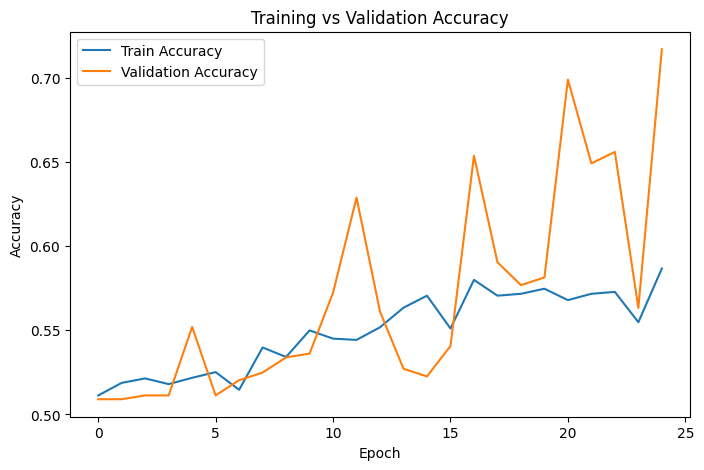

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

Loss Graph (VERY important)

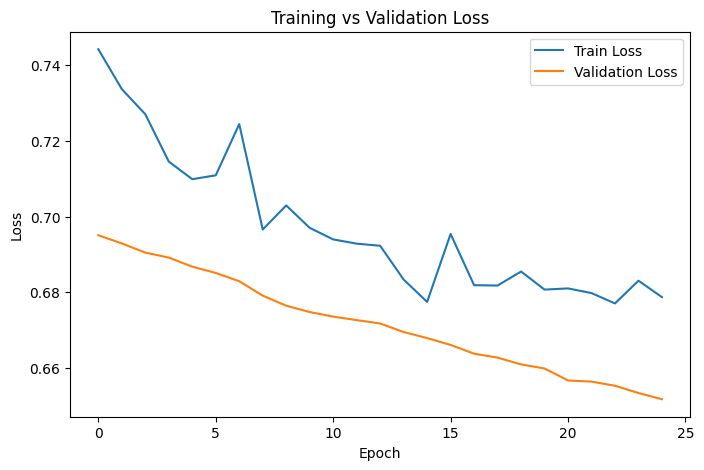

In [46]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

Precision & Recall Graph (extra — since you used them)

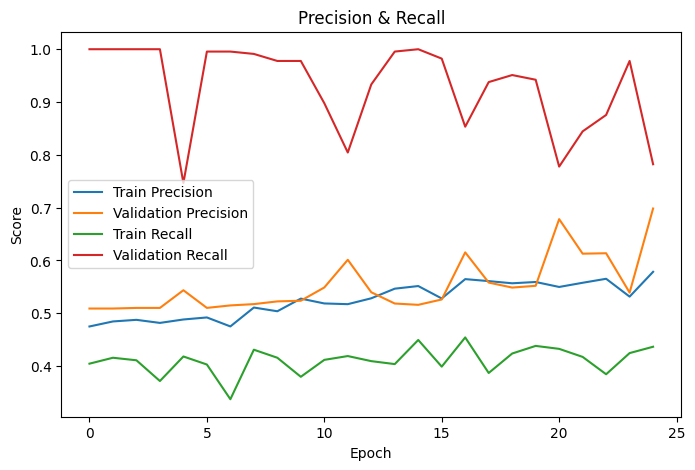

In [47]:
plt.figure(figsize=(8,5))

plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Validation Precision')

plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')

plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Precision & Recall')
plt.legend()

plt.show()